# 10 - DiT Raw Image Experimental (Non-Generative)

Experimental non-generative benchmark using **raw document images**.
- No OCR required for model input.
- No generative AI.
- Fine-tunes DiT on the existing 5-class split.


## 1) Repo Inspection


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('PROJECT_ROOT:', PROJECT_ROOT)
for name in ['notebooks', 'src', 'data/processed', 'models', 'outputs', 'reports']:
    p = PROJECT_ROOT / name
    print('\n===', name, '===')
    if not p.exists():
        print('Missing:', p)
        continue
    for x in sorted([q.name for q in p.iterdir()])[:30]:
        print('-', x)


PROJECT_ROOT: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification

=== notebooks ===
- 00_dataset_download_and_preparation.ipynb
- 01_ocr_pipeline_build_and_validation.ipynb
- 02_ocr_text_plus_layout_features.ipynb
- 02b_confusion_pair_improvement.ipynb
- 05_invoice_extraction_and_evaluation.ipynb
- 07_bert_random_forest.ipynb
- 08_lda_lstm_classifier.ipynb
- 09_layoutlmv3_experimental.ipynb
- 09b_layoutlmv3_calibrated_fusion.ipynb
- 10_dit_raw_image_experimental.ipynb
- 11_layoutlmv3_large_experimental.ipynb
- 12_ensemble_sota_non_generative.ipynb
- data
- outputs

=== src ===
- __init__.py
- __pycache__
- config.py
- evaluation.py
- image_preprocessing.py
- invoice_extraction.py
- invoice_rules.py
- layout_features.py
- models_bert_rf.py
- models_layout.py
- models_lda_lstm.py
- ocr_engine.py
- utils.py
- validators.py
- zones.py

=== data/processed ===
- class_balance_by_split.csv
- dataset_summary.json
- duplicates_by_hash.csv
- duplicates_

## 2) Imports and Setup


In [2]:
import json
import random
import numpy as np
import pandas as pd
from PIL import Image

from src.evaluation import compute_metrics, metrics_dict_to_frame, confusion_matrix_df, plot_confusion_matrix, classification_report_df

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

LABELS = ['invoice', 'form', 'resume', 'email', 'budget']
label2id = {l:i for i,l in enumerate(LABELS)}
id2label = {i:l for l,i in label2id.items()}

models_dir = PROJECT_ROOT / 'models' / 'experimental' / 'dit_raw'
pred_dir = PROJECT_ROOT / 'outputs' / 'predictions'
fig_dir = PROJECT_ROOT / 'reports' / 'figures'
table_dir = PROJECT_ROOT / 'reports' / 'tables'
for p in [models_dir, pred_dir, fig_dir, table_dir]:
    p.mkdir(parents=True, exist_ok=True)


In [3]:
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'train.csv')
val_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'val.csv')
test_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'test.csv')

for split,df in [('train',train_df),('val',val_df),('test',test_df)]:
    if 'split' not in df.columns:
        df['split'] = split

print('sizes:', len(train_df), len(val_df), len(test_df))


sizes: 8777 1882 1881


## 3) Backend Check and Model Init


In [4]:
HAS_TORCH = False
HAS_TRANSFORMERS = False

try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False

try:
    from transformers import AutoImageProcessor, AutoModelForImageClassification
    HAS_TRANSFORMERS = True
except Exception:
    HAS_TRANSFORMERS = False

print('HAS_TORCH=', HAS_TORCH, 'HAS_TRANSFORMERS=', HAS_TRANSFORMERS)
if not (HAS_TORCH and HAS_TRANSFORMERS):
    raise ImportError('Install torch + transformers to run DiT notebook.')

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HAS_TORCH= True HAS_TRANSFORMERS= True
device: cpu


In [5]:
MODEL_NAME = 'microsoft/dit-large-finetuned-rvlcdip'
BATCH_SIZE = 8
EPOCHS = 3
LR = 2e-5
WEIGHT_DECAY = 0.01
DEBUG_SUBSAMPLE = None  # set int for quick runs

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(device)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `BeitImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Some weights of BeitForImageClassification were not initialized from the model checkpoint at microsoft/dit-large-finetuned-rvlcdip and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([16, 1024]) in the checkpoint and torch.Size([5, 1024]) in the model instantiated
- classifier.bias: found shape torch.Si

BeitForImageClassification(
  (beit): BeitModel(
    (embeddings): BeitEmbeddings(
      (patch_embeddings): BeitPatchEmbeddings(
        (projection): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): BeitEncoder(
      (layer): ModuleList(
        (0): BeitLayer(
          (attention): BeitAttention(
            (attention): BeitSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=False)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): BeitSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): BeitIntermediate(
            (dense): Lin

## 4) Dataset + Dataloaders


In [6]:
def resolve_image_path(file_path: str) -> Path:
    p = Path(str(file_path))
    if p.exists():
        return p
    p2 = PROJECT_ROOT / str(file_path)
    if p2.exists():
        return p2
    return p


def prep_df(df):
    out = df.copy()
    out['resolved_path'] = out['file_path'].map(lambda x: str(resolve_image_path(x)))
    bad = (~out['resolved_path'].map(lambda p: Path(p).exists())).sum()
    if bad > 0:
        print('Warning: missing files in split:', bad)
    out = out[out['resolved_path'].map(lambda p: Path(p).exists())].reset_index(drop=True)
    if DEBUG_SUBSAMPLE is not None and len(out) > DEBUG_SUBSAMPLE:
        out = out.sample(n=DEBUG_SUBSAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)
    return out

train_img_df = prep_df(train_df)
val_img_df = prep_df(val_df)
test_img_df = prep_df(test_df)

class ImgDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        image = Image.open(r['resolved_path']).convert('RGB')
        enc = processor(images=image, return_tensors='pt')
        item = {k: v.squeeze(0) for k,v in enc.items()}
        item['labels'] = torch.tensor(label2id[r['class_name']], dtype=torch.long)
        item['doc_id'] = str(r['doc_id'])
        item['true_label'] = str(r['class_name'])
        return item


def collate_fn(batch):
    out = {}
    tensor_keys = [k for k in batch[0].keys() if k not in ['doc_id', 'true_label']]
    for k in tensor_keys:
        out[k] = torch.stack([b[k] for b in batch])
    out['doc_id'] = [b['doc_id'] for b in batch]
    out['true_label'] = [b['true_label'] for b in batch]
    return out

train_loader = DataLoader(ImgDataset(train_img_df), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_fn)
val_loader = DataLoader(ImgDataset(val_img_df), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)
test_loader = DataLoader(ImgDataset(test_img_df), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)

print('loader sizes:', len(train_loader), len(val_loader), len(test_loader))


loader sizes: 1098 236 236


## 5) Train and Select Best Epoch on Validation


In [8]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


def eval_loader(model, loader):
    model.eval()
    all_doc, all_true, all_pred, all_proba = [], [], [], []
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        for batch in loader:
            labels = batch['labels'].to(device)
            inputs = {k:v.to(device) for k,v in batch.items() if k in ['pixel_values']}
            out = model(**inputs, labels=labels)
            logits = out.logits
            loss = out.loss
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred_idx = logits.argmax(dim=1).cpu().numpy()

            all_doc.extend(batch['doc_id'])
            all_true.extend(batch['true_label'])
            all_pred.extend([id2label[int(i)] for i in pred_idx])
            all_proba.append(prob)
            total_loss += float(loss.item())
            n += 1
    proba = np.vstack(all_proba) if all_proba else np.zeros((0, len(LABELS)))
    return all_doc, np.array(all_true), np.array(all_pred), proba, total_loss / max(n,1)


history = []
best_state = None
best_macro = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    for batch in train_loader:
        labels = batch['labels'].to(device)
        inputs = {k:v.to(device) for k,v in batch.items() if k in ['pixel_values']}
        optimizer.zero_grad()
        out = model(**inputs, labels=labels)
        loss = out.loss
        loss.backward()
        optimizer.step()

    _, yv_true, yv_pred, p_val, val_loss = eval_loader(model, val_loader)
    m_val = compute_metrics(yv_true, yv_pred, LABELS)
    row = {'epoch': epoch, 'val_loss': val_loss, 'val_accuracy': m_val['accuracy'], 'val_macro_f1': m_val['macro_f1'], 'val_invoice_recall': m_val['invoice_recall']}
    history.append(row)
    print(row)

    if m_val['macro_f1'] > best_macro:
        best_macro = m_val['macro_f1']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_val_cache = {'y_true': yv_true, 'y_pred': yv_pred, 'proba': p_val}
        best_epoch = epoch

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df


{'epoch': 1, 'val_loss': 0.1113226117499141, 'val_accuracy': 0.9659936238044633, 'val_macro_f1': 0.965894378472411, 'val_invoice_recall': 0.9568733153638814}
{'epoch': 2, 'val_loss': 0.1112163721700199, 'val_accuracy': 0.9659936238044633, 'val_macro_f1': 0.9658426351606847, 'val_invoice_recall': 0.9487870619946092}
{'epoch': 3, 'val_loss': 0.12998132240885504, 'val_accuracy': 0.9654622741764081, 'val_macro_f1': 0.9653054011000837, 'val_invoice_recall': 0.9299191374663073}


,epoch,val_loss,val_accuracy,val_macro_f1,val_invoice_recall
0,1,0.111323,0.965994,0.965894,0.956873
1,2,0.111216,0.965994,0.965843,0.948787
2,3,0.129981,0.965462,0.965305,0.929919


## 6) Evaluate on Test


In [9]:
val_metrics = compute_metrics(best_val_cache['y_true'], best_val_cache['y_pred'], LABELS)
doc_test, y_test_true, y_test_pred, p_test, test_loss = eval_loader(model, test_loader)
test_metrics = compute_metrics(y_test_true, y_test_pred, LABELS)

pd.concat([
    metrics_dict_to_frame(val_metrics, 'dit_raw_experimental', 'val'),
    metrics_dict_to_frame(test_metrics, 'dit_raw_experimental', 'test'),
], ignore_index=True)


,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
0,dit_raw_experimental,val,0.965994,0.965894,0.966035,0.936675,0.956873,0.933155,0.928191,0.986877,0.986877,1.000000,0.994709,0.973118,0.962766,0.936675,0.956873
1,dit_raw_experimental,test,0.973950,0.973868,0.973941,0.957105,0.959677,0.959569,0.946809,0.992021,0.981579,0.997347,0.997347,0.963542,0.984043,0.957105,0.959677


,invoice,form,resume,email,budget
invoice,357,8,1,0,6
form,15,356,1,1,3
resume,1,1,373,0,5
email,0,1,0,376,0
budget,0,5,1,0,370


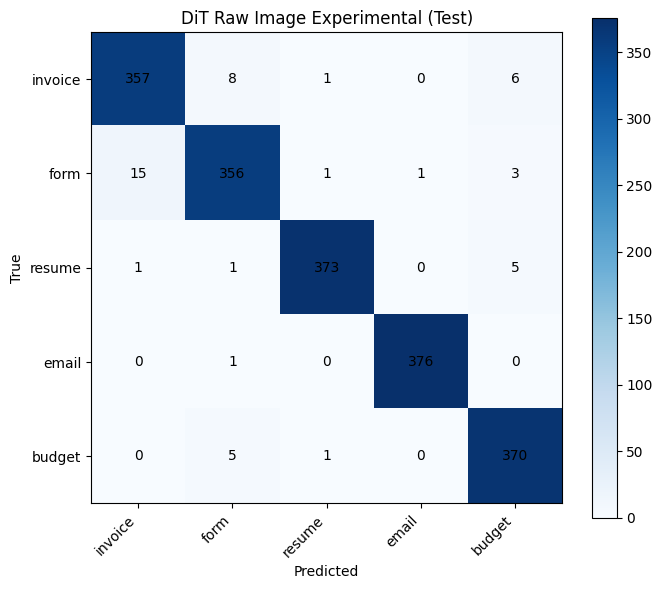

In [10]:
cm = confusion_matrix_df(y_test_true, y_test_pred, LABELS)
plot_confusion_matrix(cm, 'DiT Raw Image Experimental (Test)', save_path=fig_dir / 'dit_raw_confusion_matrix.png')
cm


## 7) Save Artifacts


In [11]:
# predictions
val_pred_df = pd.DataFrame({
    'doc_id': val_img_df['doc_id'].astype(str).tolist(),
    'true_label': best_val_cache['y_true'],
    'pred_label': best_val_cache['y_pred'],
    'split': 'val',
    'model_name': 'dit_raw_experimental',
})
for i,lab in enumerate(LABELS):
    val_pred_df[f'confidence_{lab}'] = best_val_cache['proba'][:, i]


test_pred_df = pd.DataFrame({
    'doc_id': doc_test,
    'true_label': y_test_true,
    'pred_label': y_test_pred,
    'split': 'test',
    'model_name': 'dit_raw_experimental',
})
for i,lab in enumerate(LABELS):
    test_pred_df[f'confidence_{lab}'] = p_test[:, i]

val_pred_df.to_csv(pred_dir / 'dit_raw_val_predictions.csv', index=False)
test_pred_df.to_csv(pred_dir / 'dit_raw_test_predictions.csv', index=False)

metrics_df = pd.concat([
    metrics_dict_to_frame(val_metrics, 'dit_raw_experimental', 'val'),
    metrics_dict_to_frame(test_metrics, 'dit_raw_experimental', 'test'),
], ignore_index=True)
metrics_df.to_csv(table_dir / 'dit_raw_metrics.csv', index=False)
classification_report_df(y_test_true, y_test_pred, LABELS).to_csv(table_dir / 'dit_raw_classification_report_test.csv')
history_df.to_csv(table_dir / 'dit_raw_training_history.csv', index=False)

torch.save(model.state_dict(), models_dir / 'dit_raw_state_dict.pt')
with open(models_dir / 'dit_raw_training_config.json', 'w', encoding='utf-8') as f:
    json.dump({'model_name': MODEL_NAME, 'labels': LABELS, 'epochs': EPOCHS, 'lr': LR, 'weight_decay': WEIGHT_DECAY, 'best_epoch': best_epoch, 'best_val_macro_f1': best_macro}, f, indent=2)

print('saved outputs for notebook 10')


saved outputs for notebook 10
